In [1]:
import pandas as pd
from pathlib import Path

try:
    from pymongo import MongoClient
except ImportError:
    MongoClient = None
    print("Biblioteka pymongo nie jest zainstalowana — spróbuję użyć lokalnego pliku JSON jako fallbacku.")

In [2]:
client = None
db = None
collection = None

if MongoClient is not None:
    try:
        client = MongoClient("mongodb://localhost:27017", serverSelectionTimeoutMS=3000)
        db = client["genai_analysis"]
        collection = db["analysis"]

        # test połączenia
        client.admin.command("ping")
        print("Połączono z MongoDB")
    except Exception as exc:
        print("Nie udało się połączyć z MongoDB. Notebook spróbuje użyć lokalnego pliku JSON jako fallbacku.")
        print("Szczegóły:", repr(exc))
        client = None
        db = None
        collection = None

Połączono z MongoDB


In [3]:
if collection is not None:
    docs = list(collection.find())
else:
    docs = []

print(f"Pobrano dokumentów z MongoDB: {len(docs):,}")

Pobrano dokumentów z MongoDB: 75,859


In [4]:
if docs:
    df = pd.DataFrame(docs)
else:
    # Fallback przydatny do testowania notebooka poza środowiskiem z MongoDB.
    # W pełnej analizie najlepiej używać danych z kolekcji MongoDB.
    df = pd.DataFrame()
    for fallback_path in [Path("test.json"), Path("test(1).json")]:
        if fallback_path.exists():
            df = pd.read_json(fallback_path)
            print(f"Wczytano fallback z pliku: {fallback_path.resolve()}")
            break

print(f"Rozmiar df: {df.shape}")

Rozmiar df: (75859, 9)


In [5]:
if len(df):
    display(df)
    display(df.info())
else:
    print("DataFrame jest pusty. Sprawdź połączenie z MongoDB albo dostępność pliku test.json.")

,_id,dataset_id,prompt,prompt_id,reference_output,source_context,source_metadata,tags,task_type
0,pr_codeqa_000001,ds_codeqa,What does the code make ?,pr_codeqa_000001,a suite,"def MakeSuiteFromDict(d, label=None):\n\tsuite...",{'source_dataset': 'vm2825/CodeQA-dataset'},"[codeqa, software-engineering, source-code-com...",code_qa
1,pr_codeqa_000002,ds_codeqa,Does the code make a suite ?,pr_codeqa_000002,Yes,"def MakeSuiteFromDict(d, label=None):\n\tsuite...",{'source_dataset': 'vm2825/CodeQA-dataset'},"[codeqa, software-engineering, source-code-com...",code_qa
2,pr_codeqa_000003,ds_codeqa,Does the code receive a message from a pull su...,pr_codeqa_000003,Yes,"def receive_message(topic_name, subscription_n...",{'source_dataset': 'vm2825/CodeQA-dataset'},"[codeqa, software-engineering, source-code-com...",code_qa
3,pr_codeqa_000004,ds_codeqa,What does the code receive from a pull subscri...,pr_codeqa_000004,a message,"def receive_message(topic_name, subscription_n...",{'source_dataset': 'vm2825/CodeQA-dataset'},"[codeqa, software-engineering, source-code-com...",code_qa
4,pr_codeqa_000005,ds_codeqa,What be an explicit budget used only ?,pr_codeqa_000005,to create the campaign,def CreateSharedBudget(client):\n\tbudget_serv...,{'source_dataset': 'vm2825/CodeQA-dataset'},"[codeqa, software-engineering, source-code-com...",code_qa
...,...,...,...,...,...,...,...,...,...
75854,pr_codeqa_076836,ds_codeqa,What does this function do?,pr_codeqa_076836,Returns context variables helpful for debugging.,def debug(request):\n\tcontext_extras = {}\n\t...,{'source_dataset': 'vm2825/CodeQA-dataset'},"[codeqa, software-engineering, source-code-com...",code_qa
75855,pr_codeqa_076837,ds_codeqa,What does this function do?,pr_codeqa_076837,Get the cascade precision.,def getPrecision(xmlElement):\n\treturn xmlEle...,{'source_dataset': 'vm2825/CodeQA-dataset'},"[codeqa, software-engineering, source-code-com...",code_qa
75856,pr_codeqa_076838,ds_codeqa,What does this function do?,pr_codeqa_076838,"Run a qutebrowser command.\nThe suffix ""with c...",@bdd.when(bdd.parsers.parse('I\trun\t{command}...,{'source_dataset': 'vm2825/CodeQA-dataset'},"[codeqa, software-engineering, source-code-com...",code_qa
75857,pr_codeqa_076839,ds_codeqa,What does this function do?,pr_codeqa_076839,"Returns the host component, with a port specif...","def hostport(scheme, host, port):\n\tif ((port...",{'source_dataset': 'vm2825/CodeQA-dataset'},"[codeqa, software-engineering, source-code-com...",code_qa


<class 'pandas.DataFrame'>
RangeIndex: 75859 entries, 0 to 75858
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   _id               75859 non-null  str   
 1   dataset_id        75859 non-null  str   
 2   prompt            75859 non-null  str   
 3   prompt_id         75859 non-null  str   
 4   reference_output  75859 non-null  str   
 5   source_context    75859 non-null  str   
 6   source_metadata   75859 non-null  object
 7   tags              75859 non-null  object
 8   task_type         75859 non-null  str   
dtypes: object(2), str(7)
memory usage: 5.2+ MB


None

In [6]:
if len(df):
    df.head(10).to_json("test.json")
    print("Zapisano pierwsze 10 rekordów do test.json")
else:
    print("Pominięto eksport test.json, bo df jest pusty.")

Zapisano pierwsze 10 rekordów do test.json


In [7]:
if len(df) and "source_context" in df.columns:
    display(df.iloc[0]["source_context"])
else:
    print("Brak danych albo kolumny source_context.")

'def MakeSuiteFromDict(d, label=None):\n\tsuite = Suite(label=label)\n\tsuite.SetDict(d)\n\tsuite.Normalize()\n\treturn suite'

# Rozszerzona analiza bazy CodeQA

Poniższe sekcje rozszerzają notebook o analizę jakości danych, eksplorację pól tekstowych, analizę kodu źródłowego, wykrywanie duplikatów/leakage'u oraz rekomendacje dotyczące splitu train/test.

Notebook zakłada, że wcześniej powstała ramka `df` z MongoDB. Jeżeli `df` nie istnieje albo jest pusta, kod spróbuje pomocniczo wczytać lokalny plik `test.json` wygenerowany w początkowych komórkach.

In [8]:
# Biblioteki używane w rozszerzonej analizie
import ast
import hashlib
import json
import math
import os
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_columns", 80)

# Fallback na próbkę, jeśli notebook jest uruchamiany bez MongoDB / bez wcześniejszych komórek.
if "df" not in globals() or df is None or len(df) == 0:
    fallback_candidates = [Path("test.json"), Path("test(1).json")]
    for fallback_path in fallback_candidates:
        if fallback_path.exists():
            df = pd.read_json(fallback_path)
            print(f"Wczytano fallback: {fallback_path.resolve()}")
            break
    else:
        raise RuntimeError("Brak ramki df i brak pliku test.json/test(1).json. Uruchom najpierw komórki pobierające dane z MongoDB.")

df = df.copy()
print(f"Liczba rekordów: {len(df):,}")
print(f"Liczba kolumn: {len(df.columns):,}")
display(df.head())

Liczba rekordów: 75,859
Liczba kolumn: 9


,_id,dataset_id,prompt,prompt_id,reference_output,source_context,source_metadata,tags,task_type
0,pr_codeqa_000001,ds_codeqa,What does the code make ?,pr_codeqa_000001,a suite,"def MakeSuiteFromDict(d, label=None):\n\tsuite = Suite(label=label)\n\tsuite.SetDict(d)\n\tsuite.Normalize()\n\treturn suite",{'source_dataset': 'vm2825/CodeQA-dataset'},"[codeqa, software-engineering, source-code-comprehension, code-qa]",code_qa
1,pr_codeqa_000002,ds_codeqa,Does the code make a suite ?,pr_codeqa_000002,Yes,"def MakeSuiteFromDict(d, label=None):\n\tsuite = Suite(label=label)\n\tsuite.SetDict(d)\n\tsuite.Normalize()\n\treturn suite",{'source_dataset': 'vm2825/CodeQA-dataset'},"[codeqa, software-engineering, source-code-comprehension, code-qa]",code_qa
2,pr_codeqa_000003,ds_codeqa,Does the code receive a message from a pull subscription ?,pr_codeqa_000003,Yes,"def receive_message(topic_name, subscription_name):\n\tpubsub_client = pubsub.Client()\n\ttopic = pubsub_client.topic(topic_name)\n\tsubscription = topic.subscription(subscript...",{'source_dataset': 'vm2825/CodeQA-dataset'},"[codeqa, software-engineering, source-code-comprehension, code-qa]",code_qa
3,pr_codeqa_000004,ds_codeqa,What does the code receive from a pull subscription ?,pr_codeqa_000004,a message,"def receive_message(topic_name, subscription_name):\n\tpubsub_client = pubsub.Client()\n\ttopic = pubsub_client.topic(topic_name)\n\tsubscription = topic.subscription(subscript...",{'source_dataset': 'vm2825/CodeQA-dataset'},"[codeqa, software-engineering, source-code-comprehension, code-qa]",code_qa
4,pr_codeqa_000005,ds_codeqa,What be an explicit budget used only ?,pr_codeqa_000005,to create the campaign,"def CreateSharedBudget(client):\n\tbudget_service = client.GetService('BudgetService', version='v201609')\n\tbudget = {'name': ('Shared \tInterplanetary \tBudget \t#%s' % uuid....",{'source_dataset': 'vm2825/CodeQA-dataset'},"[codeqa, software-engineering, source-code-comprehension, code-qa]",code_qa


## 1. Walidacja struktury i podstawowy profil danych

Ta część sprawdza, czy dataset ma oczekiwane kolumny oraz pokazuje braki, typy danych i liczność wartości unikalnych. To jest punkt startowy przed każdą bardziej zaawansowaną analizą.

In [9]:
EXPECTED_COLUMNS = [
    "_id",
    "dataset_id",
    "prompt",
    "prompt_id",
    "reference_output",
    "source_context",
    "source_metadata",
    "tags",
    "task_type",
]

present_columns = [c for c in EXPECTED_COLUMNS if c in df.columns]
missing_columns = [c for c in EXPECTED_COLUMNS if c not in df.columns]
extra_columns = [c for c in df.columns if c not in EXPECTED_COLUMNS]

structure_report = pd.DataFrame({
    "metryka": ["rekordy", "kolumny", "oczekiwane kolumny obecne", "oczekiwane kolumny brakujące", "dodatkowe kolumny"],
    "wartość": [len(df), len(df.columns), len(present_columns), len(missing_columns), len(extra_columns)],
    "szczegóły": ["", "", present_columns, missing_columns, extra_columns],
})
display(structure_report)

profile = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "missing_count": [df[c].isna().sum() for c in df.columns],
    "missing_pct": [df[c].isna().mean() * 100 for c in df.columns],
    "unique_count": [df[c].astype(str).nunique(dropna=True) for c in df.columns],
})
profile = profile.sort_values(["missing_pct", "unique_count"], ascending=[False, True])
display(profile)

,metryka,wartość,szczegóły
0,rekordy,75859,
1,kolumny,9,
2,oczekiwane kolumny obecne,9,"[_id, dataset_id, prompt, prompt_id, reference_output, source_context, source_metadata, tags, task_type]"
3,oczekiwane kolumny brakujące,0,[]
4,dodatkowe kolumny,0,[]


,column,dtype,missing_count,missing_pct,unique_count
1,dataset_id,str,0,0.0,1
6,source_metadata,object,0,0.0,1
7,tags,object,0,0.0,1
8,task_type,str,0,0.0,1
2,prompt,str,0,0.0,42315
5,source_context,str,0,0.0,48734
4,reference_output,str,0,0.0,52242
0,_id,str,0,0.0,75859
3,prompt_id,str,0,0.0,75859


## 2. Funkcje pomocnicze i cechy pochodne

Tworzymy kopię danych `df_features` z dodatkowymi cechami: długości tekstów, typ pytania, typ odpowiedzi, hash kontekstu kodu, metryki kodu, overlap prompt–odpowiedź–kod oraz prosta miara trudności.

In [10]:
def is_missing(x):
    if x is None:
        return True
    if isinstance(x, float) and pd.isna(x):
        return True
    return False


def as_str(x):
    if is_missing(x):
        return ""
    if isinstance(x, (dict, list, tuple, set)):
        try:
            return json.dumps(x, ensure_ascii=False, sort_keys=True)
        except TypeError:
            return str(x)
    return str(x)


def normalize_text(text):
    text = as_str(text).lower()
    text = re.sub(r"[^a-z0-9_ąćęłńóśźż]+", " ", text, flags=re.IGNORECASE)
    return re.sub(r"\s+", " ", text).strip()


def tokenize(text):
    return re.findall(r"[a-zA-Z_][a-zA-Z0-9_]*|\d+|[ąćęłńóśźżĄĆĘŁŃÓŚŹŻ]+", as_str(text).lower())


def stable_hash(text):
    return hashlib.md5(as_str(text).encode("utf-8")).hexdigest()


def parse_tags(value):
    if is_missing(value):
        return []
    if isinstance(value, list):
        return [as_str(v) for v in value]
    if isinstance(value, tuple):
        return [as_str(v) for v in value]
    if isinstance(value, str):
        s = value.strip()
        if not s:
            return []
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, (list, tuple, set)):
                return [as_str(v) for v in parsed]
        except Exception:
            pass
        return [s]
    return [as_str(value)]


def extract_source_dataset(value):
    if is_missing(value):
        return ""
    if isinstance(value, dict):
        return as_str(value.get("source_dataset", ""))
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            if isinstance(parsed, dict):
                return as_str(parsed.get("source_dataset", ""))
        except Exception:
            pass
    return ""


def classify_question(prompt):
    p = normalize_text(prompt)
    if not p:
        return "empty"
    first = p.split()[0]
    yes_no_starts = {
        "does", "do", "did", "is", "are", "was", "were", "be", "can", "could",
        "should", "would", "will", "has", "have", "had"
    }
    if first in yes_no_starts:
        return "yes_no"
    if first in {"what", "which", "who", "where", "when", "why", "how"}:
        return first
    return "other"


def classify_answer(answer):
    a = normalize_text(answer)
    if not a:
        return "empty"
    if a in {"yes", "no", "true", "false"}:
        return "boolean"
    if re.fullmatch(r"[-+]?\d+(\.\d+)?", a):
        return "numeric"
    n_words = len(a.split())
    if n_words <= 3:
        return "short_phrase"
    if n_words <= 10:
        return "medium_phrase"
    return "long_text"


def safe_ratio(num, den):
    return 0.0 if den == 0 else num / den


def answer_overlap(answer, container_text):
    ans_tokens = tokenize(answer)
    if not ans_tokens:
        return 0.0
    container_tokens = set(tokenize(container_text))
    return sum(t in container_tokens for t in ans_tokens) / len(ans_tokens)


def answer_exact_in(answer, container_text):
    ans = normalize_text(answer)
    cont = normalize_text(container_text)
    return bool(ans) and ans in cont


def regex_count(pattern, text):
    return len(re.findall(pattern, as_str(text), flags=re.MULTILINE))


def extract_code_features(code):
    code = as_str(code)
    lines = code.splitlines()
    nonempty_lines = [l for l in lines if l.strip()]
    comment_lines = [l for l in nonempty_lines if l.strip().startswith("#")]

    function_names = re.findall(r"^\s*def\s+([A-Za-z_]\w*)\s*\(", code, flags=re.MULTILINE)
    class_names = re.findall(r"^\s*class\s+([A-Za-z_]\w*)", code, flags=re.MULTILINE)
    call_candidates = re.findall(r"\b([A-Za-z_]\w*)\s*\(", code)
    excluded_calls = {"if", "for", "while", "with", "def", "class", "return", "print"}
    call_names = [c for c in call_candidates if c not in excluded_calls]

    features = {
        "code_chars": len(code),
        "code_lines": len(lines),
        "code_nonempty_lines": len(nonempty_lines),
        "code_comment_lines": len(comment_lines),
        "function_count": len(function_names),
        "function_names": function_names,
        "class_count": len(class_names),
        "class_names": class_names,
        "return_count": regex_count(r"\breturn\b", code),
        "if_count": regex_count(r"\bif\b", code),
        "for_count": regex_count(r"\bfor\b", code),
        "while_count": regex_count(r"\bwhile\b", code),
        "try_count": regex_count(r"\btry\b", code),
        "with_count": regex_count(r"\bwith\b", code),
        "raise_count": regex_count(r"\braise\b", code),
        "call_count_regex": len(call_names),
        "unique_call_count_regex": len(set(call_names)),
        "call_names_top": Counter(call_names).most_common(10),
    }

    # Próba parsowania AST. Część kodu może być w składni Python 2, więc porażka parsowania nie jest błędem analizy.
    try:
        tree = ast.parse(code)
        features["ast_parse_ok"] = True
        features["ast_node_count"] = sum(1 for _ in ast.walk(tree))
        features["ast_call_count"] = sum(isinstance(n, ast.Call) for n in ast.walk(tree))
    except Exception as exc:
        features["ast_parse_ok"] = False
        features["ast_node_count"] = np.nan
        features["ast_call_count"] = np.nan
        features["ast_parse_error"] = type(exc).__name__
    return features


def difficulty_bucket(series):
    if series.nunique(dropna=True) < 3:
        return pd.Series(["medium"] * len(series), index=series.index)
    q1, q2 = series.quantile([0.33, 0.66])
    def bucket(x):
        if x <= q1:
            return "easy"
        if x <= q2:
            return "medium"
        return "hard"
    return series.apply(bucket)

In [11]:
df_features = df.copy()

# Upewniamy się, że brakujące kolumny istnieją jako puste wartości. Dzięki temu kolejne komórki są odporne na częściowe dane.
for col in EXPECTED_COLUMNS:
    if col not in df_features.columns:
        df_features[col] = np.nan

# Teksty i długości
for col in ["prompt", "reference_output", "source_context"]:
    df_features[f"{col}_str"] = df_features[col].apply(as_str)
    df_features[f"{col}_chars"] = df_features[f"{col}_str"].str.len()
    df_features[f"{col}_words"] = df_features[f"{col}_str"].apply(lambda x: len(tokenize(x)))

# Typy pytań i odpowiedzi
df_features["question_type"] = df_features["prompt"].apply(classify_question)
df_features["answer_type"] = df_features["reference_output"].apply(classify_answer)
df_features["is_boolean_answer"] = df_features["answer_type"].eq("boolean")

# Tagi i metadane
df_features["tags_list"] = df_features["tags"].apply(parse_tags)
df_features["tag_count"] = df_features["tags_list"].apply(len)
df_features["source_dataset"] = df_features["source_metadata"].apply(extract_source_dataset)

# Hash kontekstu kodu — kluczowy do grupowania i poprawnego splitu train/test.
df_features["source_context_hash"] = df_features["source_context"].apply(stable_hash)
df_features["prompt_hash"] = df_features["prompt"].apply(stable_hash)
df_features["qa_hash"] = (df_features["prompt_str"] + "\n---\n" + df_features["reference_output_str"]).apply(stable_hash)

# Cechy kodu
code_feature_rows = df_features["source_context"].apply(extract_code_features)
code_features = pd.json_normalize(code_feature_rows)
df_features = pd.concat([df_features.reset_index(drop=True), code_features.reset_index(drop=True)], axis=1)

# Overlap i potencjalny leakage
df_features["answer_exact_in_prompt"] = df_features.apply(lambda r: answer_exact_in(r["reference_output"], r["prompt"]), axis=1)
df_features["answer_exact_in_code"] = df_features.apply(lambda r: answer_exact_in(r["reference_output"], r["source_context"]), axis=1)
df_features["answer_token_overlap_prompt"] = df_features.apply(lambda r: answer_overlap(r["reference_output"], r["prompt"]), axis=1)
df_features["answer_token_overlap_code"] = df_features.apply(lambda r: answer_overlap(r["reference_output"], r["source_context"]), axis=1)

df_features["potential_prompt_leakage"] = (
    ~df_features["is_boolean_answer"]
    & ((df_features["answer_exact_in_prompt"]) | (df_features["answer_token_overlap_prompt"] >= 0.75))
)
df_features["potential_extractive_from_code"] = (
    (df_features["answer_exact_in_code"]) | (df_features["answer_token_overlap_code"] >= 0.75)
)

# Liczba pytań przypadających na ten sam fragment kodu
df_features["questions_per_code_context"] = df_features.groupby("source_context_hash")["prompt"].transform("count")
df_features["unique_answers_per_code_context"] = df_features.groupby("source_context_hash")["reference_output_str"].transform("nunique")

# Prosty proxy-score trudności. To nie jest ground truth, ale dobry punkt startowy do audytu próbek.
df_features["control_flow_count"] = df_features[["if_count", "for_count", "while_count", "try_count", "with_count"]].sum(axis=1)
df_features["difficulty_score"] = (
    np.log1p(df_features["code_nonempty_lines"].fillna(0))
    + 0.40 * np.log1p(df_features["unique_call_count_regex"].fillna(0))
    + 0.35 * df_features["control_flow_count"].fillna(0)
    + 0.75 * (~df_features["answer_exact_in_code"]).astype(int)
    + 0.75 * (~df_features["answer_exact_in_prompt"]).astype(int)
    + 0.50 * (~df_features["question_type"].eq("yes_no")).astype(int)
)
df_features["difficulty_bucket"] = difficulty_bucket(df_features["difficulty_score"])

display(df_features[[
    "_id", "prompt", "reference_output", "question_type", "answer_type", "code_nonempty_lines",
    "function_names", "answer_exact_in_prompt", "answer_exact_in_code",
    "answer_token_overlap_prompt", "answer_token_overlap_code", "difficulty_score", "difficulty_bucket"
]].head(20))

,_id,prompt,reference_output,question_type,answer_type,code_nonempty_lines,function_names,answer_exact_in_prompt,answer_exact_in_code,answer_token_overlap_prompt,answer_token_overlap_code,difficulty_score,difficulty_bucket
0,pr_codeqa_000001,What does the code make ?,a suite,what,short_phrase,5,[MakeSuiteFromDict],False,False,0.000000,0.500000,4.435535,easy
1,pr_codeqa_000002,Does the code make a suite ?,Yes,yes_no,boolean,5,[MakeSuiteFromDict],False,False,0.000000,0.000000,3.935535,easy
2,pr_codeqa_000003,Does the code receive a message from a pull subscription ?,Yes,yes_no,boolean,10,[receive_message],False,False,0.000000,0.000000,5.826785,medium
3,pr_codeqa_000004,What does the code receive from a pull subscription ?,a message,what,short_phrase,10,[receive_message],False,True,0.500000,0.500000,5.576785,medium
4,pr_codeqa_000005,What be an explicit budget used only ?,to create the campaign,what,medium_phrase,6,[CreateSharedBudget],False,False,0.000000,0.000000,4.589685,easy
5,pr_codeqa_000006,Be an explicit budget used to create the campaign only ?,Yes,yes_no,boolean,6,[CreateSharedBudget],False,False,0.000000,0.000000,4.089685,easy
6,pr_codeqa_000007,What be used to create the campaign only ?,an explicit budget,what,short_phrase,6,[CreateSharedBudget],False,False,0.000000,0.333333,4.589685,easy
7,pr_codeqa_000008,What does the code get ?,the plugins directory path,what,medium_phrase,2,[getPluginsDirectoryPath],False,False,0.250000,0.000000,3.538057,easy
8,pr_codeqa_000009,Does the code get the plugins directory path ?,Yes,yes_no,boolean,2,[getPluginsDirectoryPath],False,False,0.000000,0.000000,3.038057,easy
9,pr_codeqa_000010,What does the code write to a file ?,an image,what,short_phrase,17,[ffmpeg_write_image],False,False,0.000000,1.000000,7.599530,hard


## 3. Jakość danych: braki, duplikaty i spójność identyfikatorów

W tej sekcji wykrywamy problemy, które mogą zaburzyć analizę lub trenowanie modelu: puste pola, powtórzone ID, duplikaty pytań, identyczne fragmenty kodu oraz niespójności między `_id` i `prompt_id`.

In [12]:
quality_rows = []

for col in EXPECTED_COLUMNS:
    quality_rows.append({
        "obszar": "missing",
        "metryka": f"missing_{col}",
        "wartość": int(df_features[col].isna().sum()),
        "odsetek_%": float(df_features[col].isna().mean() * 100),
    })

for col in ["_id", "prompt_id", "prompt_hash", "qa_hash", "source_context_hash"]:
    if col in df_features.columns:
        quality_rows.append({
            "obszar": "duplicates",
            "metryka": f"duplicated_{col}",
            "wartość": int(df_features[col].duplicated(keep=False).sum()),
            "odsetek_%": float(df_features[col].duplicated(keep=False).mean() * 100),
        })

if "_id" in df_features.columns and "prompt_id" in df_features.columns:
    id_mismatch = (df_features["_id"].apply(as_str) != df_features["prompt_id"].apply(as_str))
    quality_rows.append({
        "obszar": "id_consistency",
        "metryka": "_id != prompt_id",
        "wartość": int(id_mismatch.sum()),
        "odsetek_%": float(id_mismatch.mean() * 100),
    })

quality_report = pd.DataFrame(quality_rows).sort_values(["obszar", "odsetek_%"], ascending=[True, False])
display(quality_report)

# Przykładowe duplikaty po promptach i po kontekście kodu
prompt_dupes = df_features[df_features["prompt_hash"].duplicated(keep=False)].sort_values("prompt_hash")
code_dupes = df_features[df_features["source_context_hash"].duplicated(keep=False)].sort_values("source_context_hash")

print("Duplikaty promptów / rekordy z tym samym promptem:", len(prompt_dupes))
display(prompt_dupes[["_id", "prompt", "reference_output", "source_context_hash"]].head(20))

print("Rekordy dzielące ten sam source_context:", len(code_dupes))
display(code_dupes[["_id", "prompt", "reference_output", "source_context_hash", "questions_per_code_context"]].head(30))

,obszar,metryka,wartość,odsetek_%
13,duplicates,duplicated_source_context_hash,45139,59.503816
11,duplicates,duplicated_prompt_hash,39674,52.299661
12,duplicates,duplicated_qa_hash,15678,20.667291
9,duplicates,duplicated__id,0,0.000000
10,duplicates,duplicated_prompt_id,0,0.000000
14,id_consistency,_id != prompt_id,0,0.000000
0,missing,missing__id,0,0.000000
1,missing,missing_dataset_id,0,0.000000
2,missing,missing_prompt,0,0.000000
3,missing,missing_prompt_id,0,0.000000


Duplikaty promptów / rekordy z tym samym promptem: 39674


,_id,prompt,reference_output,source_context_hash
31611,pr_codeqa_032047,What does the code remove from a node ?,a pointer,58a80981c58e9e595a9ceda940e5ae5e
12543,pr_codeqa_012687,What does the code remove from a node ?,a pointer,fa0a549f0f403b1dde864d76fc9368eb
13006,pr_codeqa_013161,For what purpose does the code retrieve all xblocks in the course ?,for a particular category,50167a49e3baad1428e5411b894ca61a
7090,pr_codeqa_007165,For what purpose does the code retrieve all xblocks in the course ?,for a particular category,a5787c7d65d6e6763bdb4dac0f55433d
10572,pr_codeqa_010694,Do we set the src / dst ?,No,e40b6fc3bff137e82d2f0c026b9e2aaa
74225,pr_codeqa_075200,Do we set the src / dst ?,No,f7f2605f655686834f7562126d367c8d
41731,pr_codeqa_042364,What do a file handle write to disk ?,binary data,6970bbc10bc361c6b0fe0ceafd1edb25
33617,pr_codeqa_034086,What do a file handle write to disk ?,binary data,124c248b3c6bc9a308a48aba8aaaf675
2496,pr_codeqa_002503,How is the stream factory used ?,per default,4771046565ad80dd6cbc1ac0b3ca6820
15609,pr_codeqa_015797,How is the stream factory used ?,per default,8a5e63351f58aa5aa59dfcccdd6b468a


Rekordy dzielące ten sam source_context: 45139


,_id,prompt,reference_output,source_context_hash,questions_per_code_context
17062,pr_codeqa_017260,What applies that symbolizer to all features ?,a valid sld,00019ab3a8ee0add320200b88a9aaf23,5
17064,pr_codeqa_017262,What do an xml snippet represent in the appropriate elements ?,a single symbolizer,00019ab3a8ee0add320200b88a9aaf23,5
17060,pr_codeqa_017258,For what purpose do an xml snippet representing a single symbolizer in the appropriate elements wrap ?,to make it a valid sld which applies that symbolizer to all features,00019ab3a8ee0add320200b88a9aaf23,5
17063,pr_codeqa_017261,What does a valid sld apply to all features ?,that symbolizer,00019ab3a8ee0add320200b88a9aaf23,5
17061,pr_codeqa_017259,What is representing a single symbolizer in the appropriate elements ?,an xml snippet,00019ab3a8ee0add320200b88a9aaf23,5
22200,pr_codeqa_022475,What commit hash ?,the,0002e12da3322ba74a121be9566cc1c4,2
22201,pr_codeqa_022476,What does the commit ?,hash,0002e12da3322ba74a121be9566cc1c4,2
43650,pr_codeqa_044318,What caches in the localfiles cache ?,a local file on the minion,00035e464e1e3e4e96f92bbc59a631a0,2
43651,pr_codeqa_044319,Where do a local file on the minion cache ?,in the localfiles cache,00035e464e1e3e4e96f92bbc59a631a0,2
47716,pr_codeqa_048443,How does the code create a volume group ?,by using the block special devices,000a823d213af1efbd3b9817be2b384a,2


## 4. Rozkłady: typy pytań, odpowiedzi, tagi i źródła

Tu sprawdzamy, czy dataset jest zbalansowany. Szczególnie ważny jest udział pytań `yes_no` i odpowiedzi `Yes/No`, bo silna dominacja takich rekordów może prowadzić do trywialnych baseline'ów.

In [13]:
def freq_table(series, name, top_n=30):
    out = (
        series.fillna("")
        .astype(str)
        .value_counts(dropna=False)
        .head(top_n)
        .rename_axis(name)
        .reset_index(name="count")
    )
    out["pct"] = out["count"] / len(series) * 100
    return out

question_type_freq = freq_table(df_features["question_type"], "question_type")
answer_type_freq = freq_table(df_features["answer_type"], "answer_type")
top_answers = freq_table(df_features["reference_output_str"], "reference_output", top_n=30)
task_type_freq = freq_table(df_features["task_type"], "task_type")
dataset_id_freq = freq_table(df_features["dataset_id"], "dataset_id")
source_dataset_freq = freq_table(df_features["source_dataset"], "source_dataset")

tag_counter = Counter(tag for tags in df_features["tags_list"] for tag in tags)
tag_freq = pd.DataFrame(tag_counter.most_common(50), columns=["tag", "count"])
if len(tag_freq):
    tag_freq["pct_records"] = tag_freq["count"] / len(df_features) * 100

print("Typy pytań")
display(question_type_freq)
print("Typy odpowiedzi")
display(answer_type_freq)
print("Najczęstsze odpowiedzi")
display(top_answers)
print("Task type")
display(task_type_freq)
print("Dataset ID")
display(dataset_id_freq)
print("Source dataset")
display(source_dataset_freq)
print("Tagi")
display(tag_freq)

Typy pytań


,question_type,count,pct
0,what,55447,73.092184
1,how,7862,10.363965
2,where,3960,5.220211
3,other,3858,5.085751
4,when,3162,4.168260
5,yes_no,1254,1.653067
6,who,157,0.206963
7,why,142,0.187189
8,which,17,0.022410


Typy odpowiedzi


,answer_type,count,pct
0,short_phrase,36771,48.472825
1,medium_phrase,31631,41.697096
2,long_text,6114,8.059690
3,boolean,1302,1.716342
4,numeric,24,0.031638
5,empty,17,0.022410


Najczęstsze odpowiedzi


...

,dataset_id,count,pct
0,ds_codeqa,75859,100.0


Source dataset


,source_dataset,count,pct
0,vm2825/CodeQA-dataset,75859,100.0


Tagi


,tag,count,pct_records
0,codeqa,75859,100.0
1,software-engineering,75859,100.0
2,source-code-comprehension,75859,100.0
3,code-qa,75859,100.0


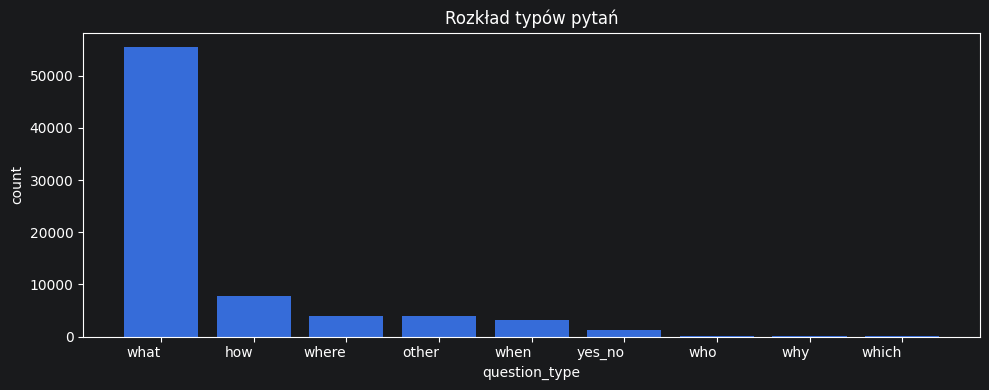

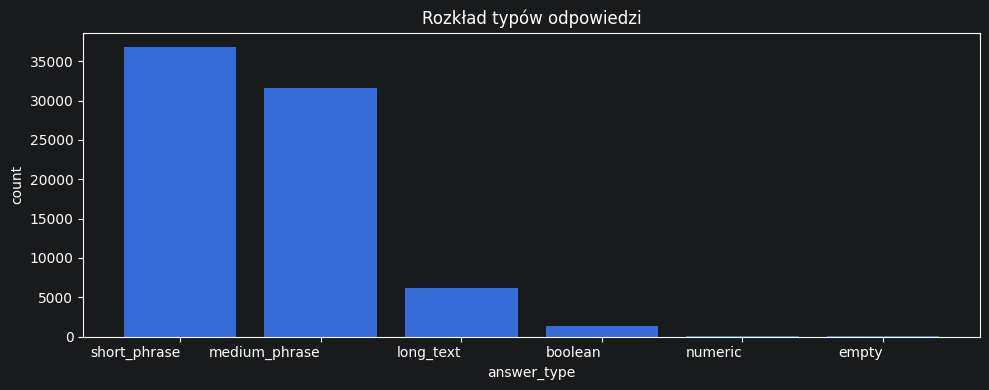

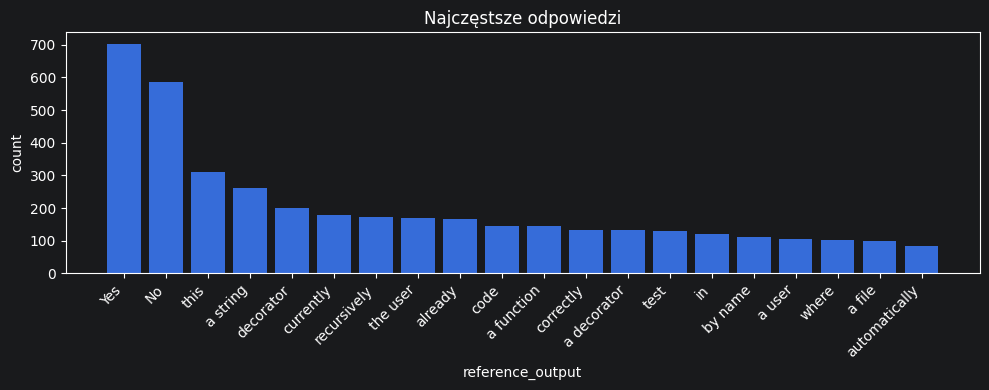

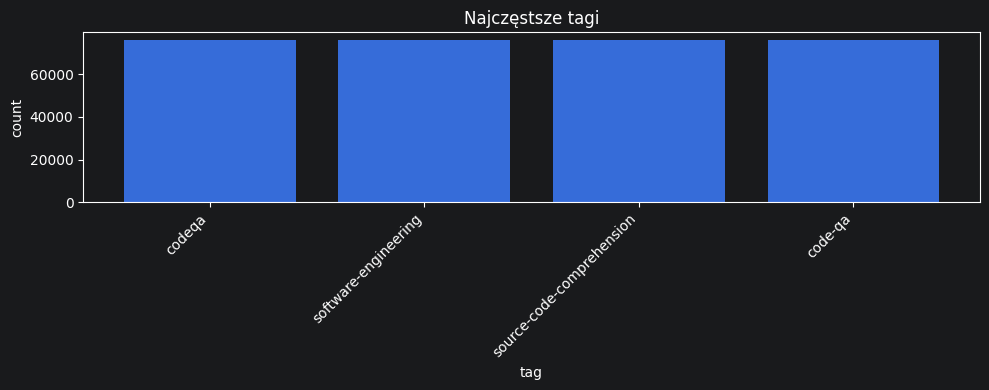

In [14]:
def plot_bar_from_freq(freq_df, x_col, y_col="count", title="", top_n=20, rotation=45):
    if freq_df.empty:
        print(f"Brak danych do wykresu: {title}")
        return
    data = freq_df.head(top_n).copy()
    plt.figure(figsize=(10, 4))
    plt.bar(data[x_col].astype(str), data[y_col])
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    plt.show()

plot_bar_from_freq(question_type_freq, "question_type", title="Rozkład typów pytań", rotation=0)
plot_bar_from_freq(answer_type_freq, "answer_type", title="Rozkład typów odpowiedzi", rotation=0)
plot_bar_from_freq(top_answers, "reference_output", title="Najczęstsze odpowiedzi", top_n=20)
plot_bar_from_freq(tag_freq, "tag", title="Najczęstsze tagi", top_n=20)

## 5. Analiza długości tekstów i kodu

Porównujemy długości promptów, odpowiedzi i fragmentów kodu. Skrajnie krótkie lub bardzo długie rekordy warto przejrzeć ręcznie, bo często są nietypowe albo problematyczne.

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing
prompt_chars,75859.0,38.228305,18.410751,12.0,18.0,23.0,27.0,31.0,46.0,73.0,106.0,303.0,0
prompt_words,75859.0,6.837093,3.086788,2.0,4.0,4.0,5.0,5.0,8.0,13.0,18.0,43.0,0
reference_output_chars,75859.0,27.747901,26.132339,1.0,2.0,4.0,11.0,20.0,35.0,73.0,138.0,343.0,0
reference_output_words,75859.0,4.844251,4.382234,0.0,1.0,1.0,2.0,3.0,6.0,13.0,23.0,53.0,0
source_context_chars,75859.0,358.484531,376.466618,16.0,45.0,71.0,156.0,279.0,477.0,858.0,1201.0,30937.0,0
source_context_words,75859.0,42.362778,43.657496,3.0,5.0,8.0,19.0,33.0,57.0,99.0,136.0,3789.0,0
code_lines,75859.0,8.971974,7.803629,2.0,2.0,2.0,4.0,7.0,12.0,21.0,29.0,514.0,0
code_nonempty_lines,75859.0,8.971974,7.803629,2.0,2.0,2.0,4.0,7.0,12.0,21.0,29.0,514.0,0


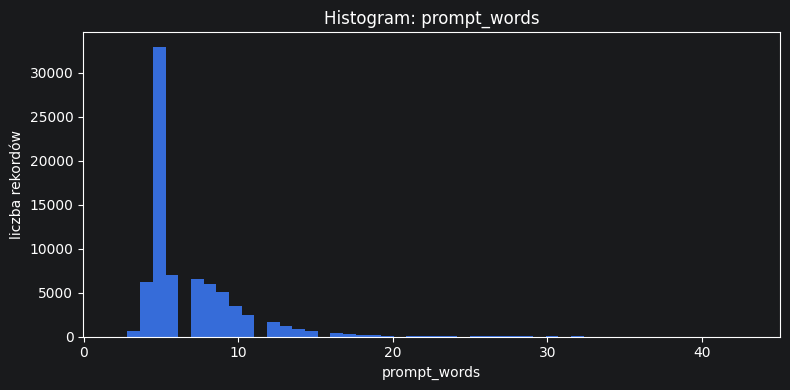

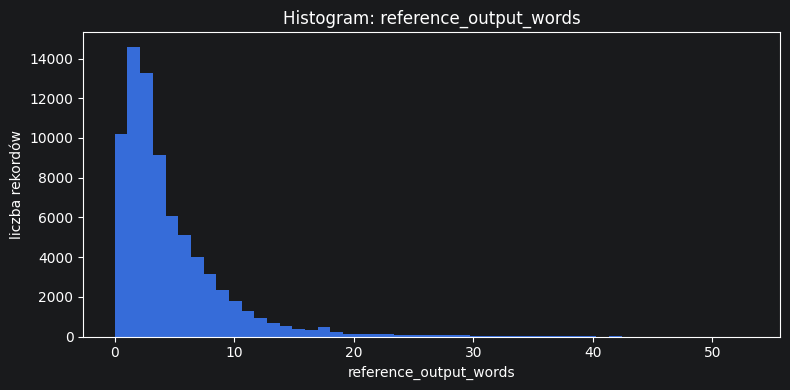

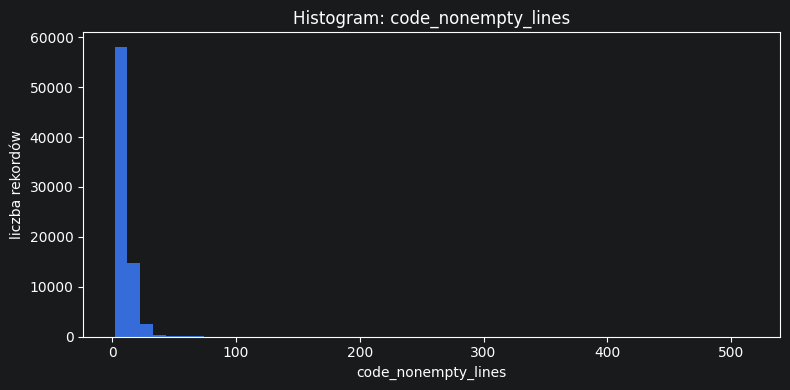

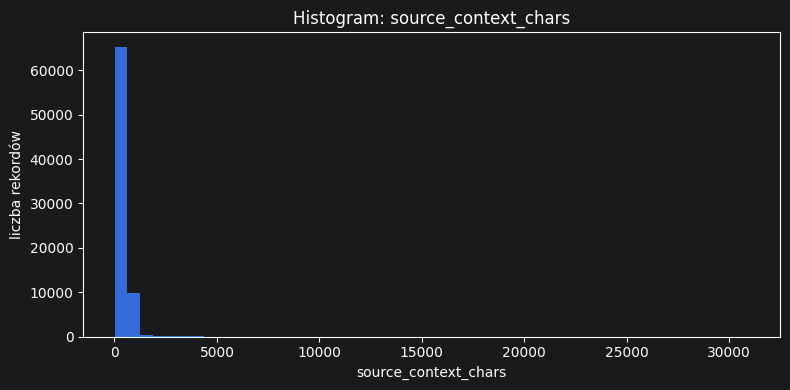

In [15]:
length_columns = [
    "prompt_chars", "prompt_words",
    "reference_output_chars", "reference_output_words",
    "source_context_chars", "source_context_words",
    "code_lines", "code_nonempty_lines",
]
length_summary = df_features[length_columns].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
length_summary["missing"] = df_features[length_columns].isna().sum()
display(length_summary)

for col in ["prompt_words", "reference_output_words", "code_nonempty_lines", "source_context_chars"]:
    plt.figure(figsize=(8, 4))
    plt.hist(df_features[col].dropna(), bins=min(50, max(5, int(np.sqrt(len(df_features))))))
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("liczba rekordów")
    plt.tight_layout()
    plt.show()

In [16]:
# Rekordy skrajne — potencjalnie warte ręcznego audytu
for col in ["prompt_words", "reference_output_words", "code_nonempty_lines"]:
    print(f"\nNajkrótsze według {col}")
    display(df_features.sort_values(col, ascending=True)[["_id", "prompt", "reference_output", col]].head(10))
    print(f"Najdłuższe według {col}")
    display(df_features.sort_values(col, ascending=False)[["_id", "prompt", "reference_output", col]].head(10))


Najkrótsze według prompt_words


,_id,prompt,reference_output,prompt_words
41353,pr_codeqa_041978,What include % } ?,a django - style,2
26023,pr_codeqa_026342,What mysql > ?,>,2
66563,pr_codeqa_067514,What reset magic ?,test %,3
66659,pr_codeqa_067610,What needs renewal ?,a certicate,3
66685,pr_codeqa_067636,What require authentication ?,tvdbclient methods,3
66385,pr_codeqa_067336,What equals initializer ?,declarator,3
66425,pr_codeqa_067376,What supports netproxies ?,a version of getattr,3
66311,pr_codeqa_067262,What need monitoring ?,the common roots,3
875,pr_codeqa_000877,What takes cr ?,a traditional - style method,3
868,pr_codeqa_000870,What lib folder ?,the apps,3


Najdłuższe według prompt_words


,_id,prompt,reference_output,prompt_words
67241,pr_codeqa_068196,What does the code get from just a code args : status_code : integer or string that can be converted to an integer default_reason : default text to be appended to the status_co...,both the http status code and description,43
20192,pr_codeqa_020428,What does the code validate because it is easy to get confusing error output when one does not install a dependency because of the fork - worker model that is both necessary fo...,the existence and basic working - ness of other programs implemented,41
35256,pr_codeqa_035757,What does the code call : term : view callable configured with a : term : view configuration that matches the : term : view name name registered against the specified context a...,the,40
15732,pr_codeqa_015920,What do a context manager for a copy of the supplied context use if no context is specified the returned context manager creates a local decimal context in a with statement : d...,a copy of the current context,39
28290,pr_codeqa_028654,What makes a new dask that slices blocks along every dimension and aggregates each dimensions slices so that the resulting block slices give the same results as the original sl...,master function for array slicing this function,39
44025,pr_codeqa_044698,What uses both the old precondition check as well as the new function fn cls : class whose check_precondition should be used as a base fn : check_precondition function to check...,a check_precondition function,39
28544,pr_codeqa_028916,What does the code call : term : view callable configured with a : term : view configuration that matches the : term : view name name registered against the specified context a...,the,38
14041,pr_codeqa_014203,What does this function take from the image_data values dictionary which flows over the wire between the registry and api servers and converts it into the location_data format ...,the legacy locations field and the newly added location_data field,37
63532,pr_codeqa_064480,What does this inject onto the ec2 service resource because the resource model is not able to express creating multiple tag resources based on the fact you can apply a set of t...,a custom create_tags method,37
44065,pr_codeqa_044739,What does the code do using http api described in URL arguments : * latitude * longitude keyword arguments : * title - the title of an article to search for * results - the max...,a wikipedia geo search for latitude and longitude,37



Najkrótsze według reference_output_words


...

,_id,prompt,reference_output,reference_output_words
60242,pr_codeqa_061178,What does this function do?,"This function takes a domain name as a parameter and then creates a certificate and key with the\ndomain name(replacing dots by underscores), finally signing the certificate us...",53
56602,pr_codeqa_057538,What does this function do?,A decorator used wrap cassandra.cqlengine.connection.execute. It counts the number of times this method is invoked\nthen compares it to the number expected. If they don\'t matc...,52
57376,pr_codeqa_058312,What does this function do?,"Used for examining the distribution of values in a set. Produces scattering as in beeswarm or column scatter plots.\nGiven a list of x-values, construct a set of y-values such ...",50
57942,pr_codeqa_058878,What does this function do?,This event is triggered on the slave instances every time a stats report is\nto be sent to the locust master. It will allow us to add our extra content-length\ndata to the dict...,49
45922,pr_codeqa_046626,What does the code get ?,the list of core observations in table table : the biom - format table object to filter sample_ids : list of sample ids of interest for the core computation fraction_for_core :...,48
47927,pr_codeqa_048665,What does the code compute ?,the standard f - test statistic for linear restriction hypothesis testing parameters r : ndarray restriction matrix r : ndarray restriction vector beta : ndarray estimated mode...,47
56849,pr_codeqa_057785,What does this function do?,Determine what column a single column id (name or index) matches in a series of column names.\nNote that integer values are *always* treated as positional identifiers. If you h...,46
66936,pr_codeqa_067889,What does the code ensure ?,that the named database is absent name the name of the database to remove user the user to connect as password the password of the user host the host to connect to port the por...,45
58928,pr_codeqa_059864,What does this function do?,Create a sparse pattern from category c with the given number of dimensions.\nThe pattern is created by setting element c to be a high random number.\nElement c-1 and c+1 are s...,43
58807,pr_codeqa_059743,What does this function do?,"Keras \'loss\' function for the REINFORCE algorithm, where y_true is the action that was\ntaken, and updates with the negative gradient will make that action more likely. We us...",42



Najkrótsze według code_nonempty_lines


,_id,prompt,reference_output,code_nonempty_lines
21888,pr_codeqa_022160,In which direction does the most recent savepoint roll ?,back,2
60653,pr_codeqa_061589,What does this function do?,Helper function to calculate sum of squares along first axis,2
60649,pr_codeqa_061585,What does this function do?,Converts an arbitrary object C{obj} to a C{tuple}.,2
60643,pr_codeqa_061579,What does this function do?,command : FOR ID EQUALS error TO expr optstep,2
60639,pr_codeqa_061575,What does this function do?,Get all backups belonging to a host.,2
60671,pr_codeqa_061607,What does this function do?,Unload the IPython extension,2
60666,pr_codeqa_061602,What does this function do?,Skin a gcode linear move text.,2
60661,pr_codeqa_061597,What does this function do?,Returns if the given model was automatically generated.,2
43770,pr_codeqa_044440,What does the code create ?,a short string representation of a float,2
9838,pr_codeqa_009957,What does the code enable ?,a service,2


Najdłuższe według code_nonempty_lines


,_id,prompt,reference_output,code_nonempty_lines
68057,pr_codeqa_069013,What does this function do?,Template settings for IFRC MENA 4W Portal,514
57633,pr_codeqa_058569,What does this function do?,Bisection algorithm that can be used to perform blind SQL injection\non an affected host,432
59958,pr_codeqa_060894,What does this function do?,This function parses the command line parameters and arguments,365
58107,pr_codeqa_059043,What does this function do?,Minifies the JavaScript,342
58650,pr_codeqa_059586,What does this function do?,Perform the code analysis.,242
59316,pr_codeqa_060252,What does this function do?,"Install just the base environment, no distutils patches etc",240
58986,pr_codeqa_059922,What does this function do?,"Install just the base environment, no distutils patches etc",232
55289,pr_codeqa_056225,What does this function do?,"Validates all models that are part of the specified app. If no app name is provided,\nvalidates all models of all installed apps. Writes errors, if any, to outfile.\nReturns nu...",210
68235,pr_codeqa_069191,What does this function do?,"Validates all models that are part of the specified app. If no app name is provided,\nvalidates all models of all installed apps. Writes errors, if any, to outfile.\nReturns nu...",206
55599,pr_codeqa_056535,What does this function do?,Generate a Volunteer Service Record,186


## 6. Analiza kodu źródłowego

Analizujemy strukturę `source_context`: liczbę funkcji, linii kodu, instrukcji sterujących, wywołań funkcji i możliwość sparsowania przez `ast`. W datasetach CodeQA część kodu może być w składni Python 2, więc `ast_parse_ok=False` nie musi oznaczać błędu danych, ale jest sygnałem do dalszej segmentacji.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
code_nonempty_lines,75859.0,NaN,NaN,NaN,8.971974,7.803629,2.0,4.0,7.0,12.0,514.0
function_count,75859.0,NaN,NaN,NaN,1.093713,0.390655,1.0,1.0,1.0,1.0,24.0
class_count,75859.0,NaN,NaN,NaN,0.010058,0.15324,0.0,0.0,0.0,0.0,9.0
return_count,75859.0,NaN,NaN,NaN,1.163501,1.072641,0.0,1.0,1.0,1.0,27.0
if_count,75859.0,NaN,NaN,NaN,1.150846,1.717786,0.0,0.0,1.0,2.0,109.0
for_count,75859.0,NaN,NaN,NaN,0.455266,0.923309,0.0,0.0,0.0,1.0,50.0
while_count,75859.0,NaN,NaN,NaN,0.038519,0.211629,0.0,0.0,0.0,0.0,5.0
try_count,75859.0,NaN,NaN,NaN,0.173453,0.48011,0.0,0.0,0.0,0.0,26.0
with_count,75859.0,NaN,NaN,NaN,0.077539,0.354478,0.0,0.0,0.0,0.0,20.0
raise_count,75859.0,NaN,NaN,NaN,0.190445,0.556536,0.0,0.0,0.0,0.0,11.0


Parsowanie AST


,ast_parse_ok,count,pct
0,True,74182,97.78932
1,False,1677,2.21068


,function_name,count
0,wrapper,599
1,decorator,381
2,main,340
3,setup_platform,253
4,__virtual__,218
5,inner,185
6,wrapped,165
7,absent,115
8,get,113
9,__init__,110


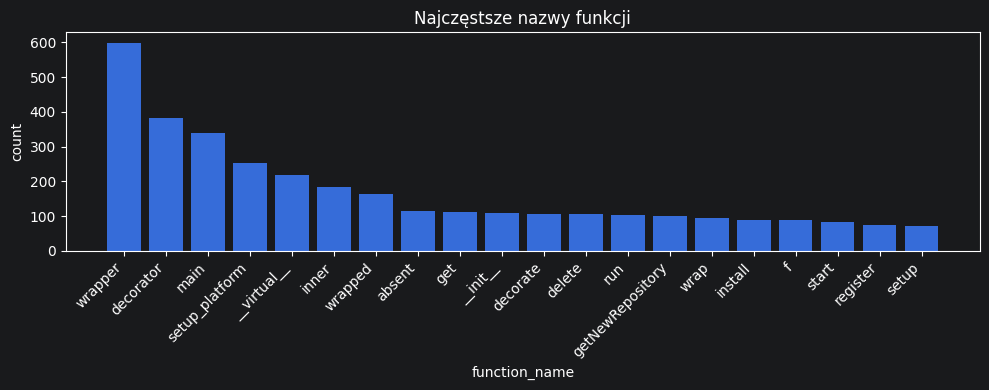

,call_name,count
0,len,10874
1,get,10842
2,format,9286
3,append,9245
4,isinstance,8396
5,join,7867
6,and,6543
7,assert,5682
8,elif,5464
9,split,4386


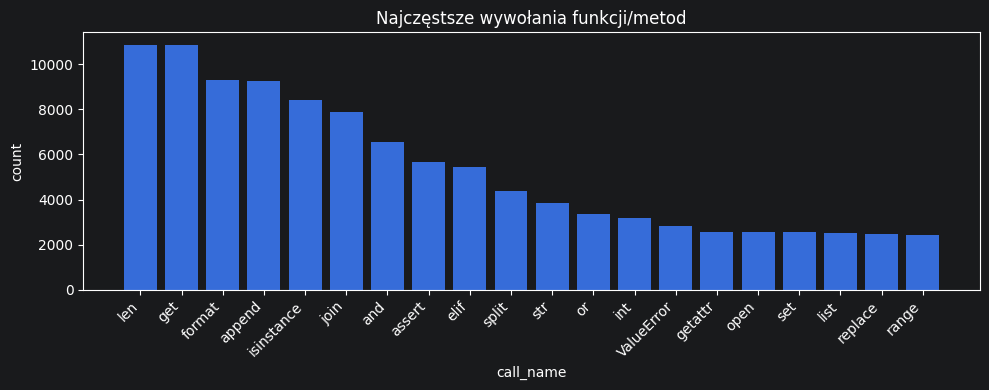

In [17]:
code_metric_cols = [
    "code_nonempty_lines", "function_count", "class_count", "return_count", "if_count", "for_count",
    "while_count", "try_count", "with_count", "raise_count", "unique_call_count_regex", "ast_parse_ok"
]
code_summary = df_features[code_metric_cols].describe(include="all").T
display(code_summary)

print("Parsowanie AST")
display(freq_table(df_features["ast_parse_ok"], "ast_parse_ok"))

# Najczęstsze nazwy funkcji
function_counter = Counter(fn for names in df_features["function_names"] for fn in names)
function_freq = pd.DataFrame(function_counter.most_common(30), columns=["function_name", "count"])
display(function_freq)
plot_bar_from_freq(function_freq, "function_name", title="Najczęstsze nazwy funkcji", top_n=20)

# Najczęstsze wywołania funkcji/metod z parsowania regexowego
call_counter = Counter()
for calls in df_features["call_names_top"]:
    for name, count in calls:
        call_counter[name] += count
call_freq = pd.DataFrame(call_counter.most_common(30), columns=["call_name", "count"])
display(call_freq)
plot_bar_from_freq(call_freq, "call_name", title="Najczęstsze wywołania funkcji/metod", top_n=20)

## 7. Grupowanie rekordów po tym samym fragmencie kodu

To ważne dla CodeQA: jeden fragment kodu może mieć wiele pytań. Przy podziale train/test nie powinno się rozdzielać tych samych lub identycznych kontekstów kodu między zbiory, bo prowadzi to do leakage'u.

,source_context_hash,records,unique_prompts,unique_answers,avg_code_lines,max_code_lines,question_types,example_prompt,example_answer,example_function_names
33046,ae6c69b1e04abc5fa1fb0f9cd3a2fc90,13,13,10,8.0,8,"{'who': 4, 'what': 7, 'yes_no': 1, 'other': 1}",Who sets the raw wsgi environment ?,i,[set_flask_request]
12140,3f6e94d4392c998a2f36f335f371c375,12,12,12,2.0,2,"{'what': 6, 'where': 3, 'how': 2, 'yes_no': 1}",What nt passs around a shared resource ?,tasks,[_link]
41934,dcb91f24ab0202804f765105402da8b8,12,12,10,5.0,5,"{'what': 6, 'when': 3, 'how': 2, 'other': 1}",What uses the quality filtering code re when not demultiplexing ?,us,[process_fastq_single_end_read_file_no_barcode]
9694,32833457a5238167987893301bfc1260,11,11,11,6.0,6,"{'what': 6, 'how': 2, 'who': 1, 'yes_no': 1, 'where': 1}",What can templates use the widget type if they want to ?,to render things differently,[annotate_form_field]
20254,6a548def1388de8294c43597328f62a1,11,11,8,14.0,14,"{'who': 3, 'when': 1, 'what': 7}",Who want custom buffering when they re using an in / out object that will be os ?,they,[bufsize_validator]
28838,9809dd4513448da478b20419feee082b,11,11,8,4.0,4,"{'where': 1, 'what': 7, 'why': 2, 'yes_no': 1}",Where did an internalerror occur for issue for issue because py test failed to get the source lines ?,in this case,[test_dont_collect_non_function_callable]
42102,dd917ee77ea8604e9253366ce5647482,11,11,11,2.0,2,"{'what': 10, 'how': 1}",What do the name change ?,to pprint,[__virtual__]
1701,08e7f4d1257e9911dd542f9b41886ca1,10,10,8,4.0,4,"{'what': 8, 'other': 1, 'where': 1}",What parses the model data to compress extra fields ?,us,[get_or_create]
1731,090b41ff39d7891b08a589241a7cef4a,10,10,7,17.0,17,"{'what': 5, 'where': 5}",What gets recycled in some cases where there are an insane number of processes being created on a system ?,a pid,[_check_cmdline]
3141,10c49d62ae7e4d4ab58a77a3bb1ea341,10,10,10,2.0,2,"{'other': 2, 'what': 5, 'where': 1, 'why': 1, 'yes_no': 1}",By how much does a stub module nt alter system state ?,at all,[file_open]


Statystyki liczby pytań na ten sam source_context


,questions_per_code
count,48734.000000
mean,1.556593
std,0.923204
min,1.000000
50%,1.000000
75%,2.000000
90%,3.000000
95%,3.000000
99%,5.000000
max,13.000000


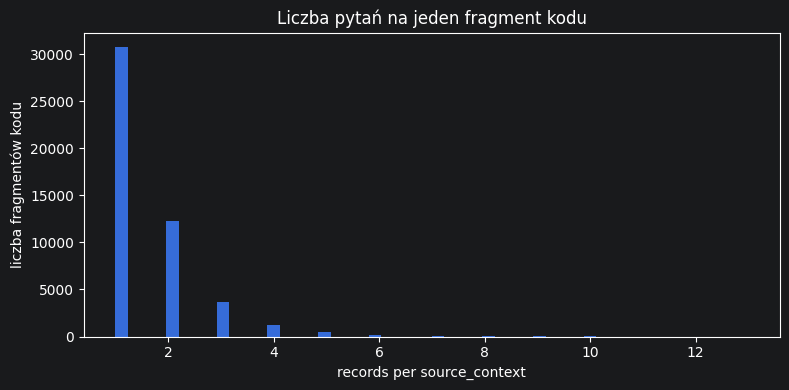

In [18]:
code_groups = (
    df_features
    .groupby("source_context_hash")
    .agg(
        records=("_id", "count"),
        unique_prompts=("prompt_str", "nunique"),
        unique_answers=("reference_output_str", "nunique"),
        avg_code_lines=("code_nonempty_lines", "mean"),
        max_code_lines=("code_nonempty_lines", "max"),
        question_types=("question_type", lambda s: dict(Counter(s))),
        example_prompt=("prompt", "first"),
        example_answer=("reference_output", "first"),
        example_function_names=("function_names", "first"),
    )
    .reset_index()
    .sort_values(["records", "unique_prompts"], ascending=False)
)

display(code_groups.head(30))

print("Statystyki liczby pytań na ten sam source_context")
display(code_groups["records"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("questions_per_code"))

plt.figure(figsize=(8, 4))
plt.hist(code_groups["records"], bins=min(50, max(5, int(np.sqrt(len(code_groups))))))
plt.title("Liczba pytań na jeden fragment kodu")
plt.xlabel("records per source_context")
plt.ylabel("liczba fragmentów kodu")
plt.tight_layout()
plt.show()

## 8. Leakage i skróty poznawcze

Sprawdzamy, czy odpowiedź jest dosłownie lub prawie dosłownie obecna w pytaniu albo kodzie. To pomaga ocenić, czy model musi rozumieć kod, czy może korzystać ze skrótów.

,metryka,count,pct
0,answer_exact_in_prompt,1087,1.432922
1,answer_exact_in_code,4279,5.640728
2,answer_token_overlap_prompt >= 0.75,1045,1.377556
3,answer_token_overlap_code >= 0.75,3709,4.889334
4,potential_prompt_leakage,1296,1.708433
5,potential_extractive_from_code,5487,7.233156
6,boolean_answers,1302,1.716342
7,yes_no_questions,1254,1.653067


Przykłady potencjalnego leakage'u z promptu


,_id,prompt,reference_output,answer_token_overlap_prompt,answer_exact_in_prompt
67,pr_codeqa_000068,What returns a list of numbers when ?,f,0.00,True
97,pr_codeqa_000098,How are they configured ?,how,1.00,True
98,pr_codeqa_000099,"How do they appear from "" show feature "" output ?",how,1.00,True
148,pr_codeqa_000149,Where do the counts differ ?,where,1.00,True
163,pr_codeqa_000164,In which direction did the values pass ?,in,1.00,True
175,pr_codeqa_000176,What produces a base64 encoding of a der formatted cms document URL ?,a,1.00,True
271,pr_codeqa_000272,What do method decorator tag as a remote procedure call ?,a method,1.00,False
578,pr_codeqa_000580,Where is this function called ?,where,1.00,True
639,pr_codeqa_000641,What converts to a binary string if it is not already one ?,a string,1.00,False
652,pr_codeqa_000654,How are memberships calculated ?,how,1.00,True


Przykłady odpowiedzi prawdopodobnie ekstrakcyjnych z kodu


,_id,prompt,reference_output,answer_token_overlap_code,answer_exact_in_code,source_context
3,pr_codeqa_000004,What does the code receive from a pull subscription ?,a message,0.5,True,"def receive_message(topic_name, subscription_name):\n\tpubsub_client = pubsub.Client()\n\ttopic = pubsub_client.topic(topic_name)\n\tsubscription = topic.subscription(subscript..."
9,pr_codeqa_000010,What does the code write to a file ?,an image,1.0,False,"def ffmpeg_write_image(filename, image, logfile=False):\n\tif (image.dtype != 'uint8'):\n\t\timage = image.astype('uint8')\n\tcmd = [get_setting('FFMPEG_BINARY'), '-y', '-s', (..."
17,pr_codeqa_000018,What does the code get if it ca nt be found ?,a token,1.0,True,"def _get_token(profile):\n\ttoken = os.environ.get('VAULT_TOKEN', profile.get('vault.token'))\n\tif (token is None):\n\t\traise CommandExecutionError('A \ttoken \twas \tnot \tc..."
19,pr_codeqa_000020,What are we using when ?,windows,0.0,True,def is_windows():\n\treturn sys.platform.startswith(u'win')
60,pr_codeqa_000061,What windows offline ?,image,1.0,True,"def installed_features(image=None):\n\treturn _get_components('Feature \tName', 'Features', 'Enabled')"
67,pr_codeqa_000068,What returns a list of numbers when ?,f,1.0,True,"def negate_all(f):\n\treturn (lambda *args, **kwargs: [(- y) for y in f(*args, **kwargs)])"
84,pr_codeqa_000085,What does the code use ?,base64,1.0,True,"def b64encode(value, *args, **kwargs):\n\treturn base64.b64encode(encode(value, *args, **kwargs))"
88,pr_codeqa_000089,What does the code run in a somewhat controlled environment ?,a setup script,1.0,False,"def run_setup(script_name, script_args=None, stop_after='run'):\n\tif (stop_after not in ('init', 'config', 'commandline', 'run')):\n\t\traise ValueError, (""invalid \tvalue \tf..."
97,pr_codeqa_000098,How are they configured ?,how,0.0,True,"def validate_feature(module, mode='show'):\n\tfeature = module.params['feature']\n\tfeature_to_be_mapped = {'show': {'nv \toverlay': 'nve', 'vn-segment-vlan-based': 'vnseg_vlan..."
98,pr_codeqa_000099,"How do they appear from "" show feature "" output ?",how,0.0,True,"def validate_feature(module, mode='show'):\n\tfeature = module.params['feature']\n\tfeature_to_be_mapped = {'show': {'nv \toverlay': 'nve', 'vn-segment-vlan-based': 'vnseg_vlan..."


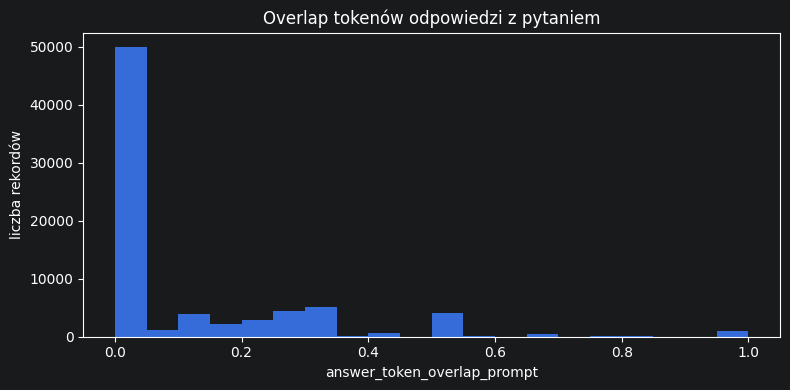

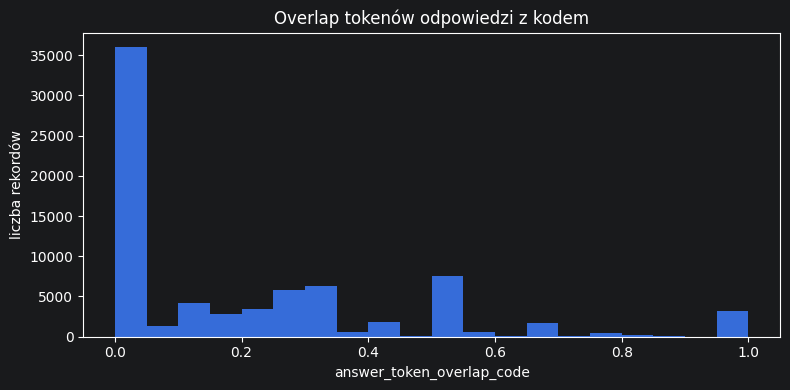

In [19]:
leakage_summary = pd.DataFrame({
    "metryka": [
        "answer_exact_in_prompt",
        "answer_exact_in_code",
        "answer_token_overlap_prompt >= 0.75",
        "answer_token_overlap_code >= 0.75",
        "potential_prompt_leakage",
        "potential_extractive_from_code",
        "boolean_answers",
        "yes_no_questions",
    ],
    "count": [
        int(df_features["answer_exact_in_prompt"].sum()),
        int(df_features["answer_exact_in_code"].sum()),
        int((df_features["answer_token_overlap_prompt"] >= 0.75).sum()),
        int((df_features["answer_token_overlap_code"] >= 0.75).sum()),
        int(df_features["potential_prompt_leakage"].sum()),
        int(df_features["potential_extractive_from_code"].sum()),
        int(df_features["is_boolean_answer"].sum()),
        int(df_features["question_type"].eq("yes_no").sum()),
    ]
})
leakage_summary["pct"] = leakage_summary["count"] / len(df_features) * 100
display(leakage_summary)

# Przykłady możliwego leakage'u prompt -> answer
print("Przykłady potencjalnego leakage'u z promptu")
display(df_features[df_features["potential_prompt_leakage"]][[
    "_id", "prompt", "reference_output", "answer_token_overlap_prompt", "answer_exact_in_prompt"
]].head(20))

# Przykłady odpowiedzi ekstrakcyjnych z kodu
print("Przykłady odpowiedzi prawdopodobnie ekstrakcyjnych z kodu")
display(df_features[df_features["potential_extractive_from_code"]][[
    "_id", "prompt", "reference_output", "answer_token_overlap_code", "answer_exact_in_code", "source_context"
]].head(10))

plt.figure(figsize=(8, 4))
plt.hist(df_features["answer_token_overlap_prompt"].dropna(), bins=20)
plt.title("Overlap tokenów odpowiedzi z pytaniem")
plt.xlabel("answer_token_overlap_prompt")
plt.ylabel("liczba rekordów")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df_features["answer_token_overlap_code"].dropna(), bins=20)
plt.title("Overlap tokenów odpowiedzi z kodem")
plt.xlabel("answer_token_overlap_code")
plt.ylabel("liczba rekordów")
plt.tight_layout()
plt.show()

## 9. Baseline'y i ryzyka ewaluacyjne

Ta część nie trenuje modelu, ale pokazuje proste baseline'y statystyczne. Jeżeli najczęstsza odpowiedź lub dominujący typ pytania daje wysoki wynik, trzeba ostrożnie interpretować wyniki modeli.

In [20]:
# Najczęstsza odpowiedź jako baseline exact match
answer_counts = df_features["reference_output_str"].value_counts(dropna=False)
majority_answer = answer_counts.index[0] if len(answer_counts) else None
majority_answer_count = int(answer_counts.iloc[0]) if len(answer_counts) else 0
majority_answer_accuracy = majority_answer_count / len(df_features) if len(df_features) else 0

# Baseline dla pytań yes/no: najczęstsza odpowiedź boolean
boolean_df = df_features[df_features["is_boolean_answer"]].copy()
if len(boolean_df):
    bool_counts = boolean_df["reference_output_str"].str.lower().value_counts(dropna=False)
    majority_bool = bool_counts.index[0]
    majority_bool_accuracy_within_boolean = bool_counts.iloc[0] / len(boolean_df)
else:
    majority_bool = None
    majority_bool_accuracy_within_boolean = np.nan

baseline_report = pd.DataFrame([
    {
        "baseline": "majority_answer_all_records",
        "predykcja": majority_answer,
        "dokładność_proxy": majority_answer_accuracy,
        "uwagi": "Exact match przy stałej odpowiedzi dla wszystkich rekordów",
    },
    {
        "baseline": "majority_boolean_answer_only_boolean_records",
        "predykcja": majority_bool,
        "dokładność_proxy": majority_bool_accuracy_within_boolean,
        "uwagi": "Baseline tylko dla rekordów z odpowiedziami boolean",
    },
    {
        "baseline": "prompt_leakage_upper_bound_proxy",
        "predykcja": "answer visible/high-overlap in prompt",
        "dokładność_proxy": df_features["potential_prompt_leakage"].mean(),
        "uwagi": "Odsetek rekordów, gdzie odpowiedź może być odgadnięta z promptu",
    },
    {
        "baseline": "extractive_from_code_upper_bound_proxy",
        "predykcja": "answer visible/high-overlap in code",
        "dokładność_proxy": df_features["potential_extractive_from_code"].mean(),
        "uwagi": "Odsetek rekordów, gdzie odpowiedź wygląda na ekstrakcyjną z kodu",
    },
])
display(baseline_report)

,baseline,predykcja,dokładność_proxy,uwagi
0,majority_answer_all_records,Yes,0.009267,Exact match przy stałej odpowiedzi dla wszystkich rekordów
1,majority_boolean_answer_only_boolean_records,yes,0.539939,Baseline tylko dla rekordów z odpowiedziami boolean
2,prompt_leakage_upper_bound_proxy,answer visible/high-overlap in prompt,0.017084,"Odsetek rekordów, gdzie odpowiedź może być odgadnięta z promptu"
3,extractive_from_code_upper_bound_proxy,answer visible/high-overlap in code,0.072332,"Odsetek rekordów, gdzie odpowiedź wygląda na ekstrakcyjną z kodu"


## 10. Trudność rekordów i audyt próbek

Miara `difficulty_score` jest heurystyczna. Służy do wskazania rekordów do ręcznego audytu oraz do sprawdzenia, czy train/test mają podobny rozkład trudności.

,difficulty_bucket,count,pct
0,hard,25773,33.974874
1,easy,25240,33.272255
2,medium,24846,32.752870


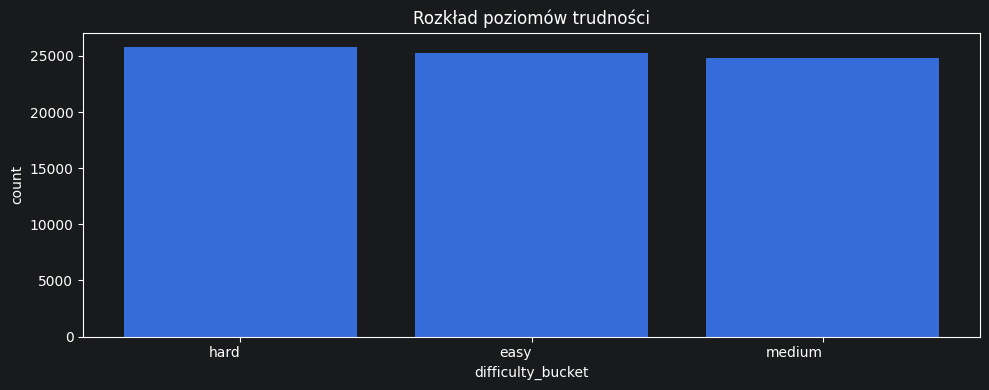

Najłatwiejsze rekordy według heurystyki


,_id,prompt,reference_output,question_type,answer_exact_in_prompt,answer_exact_in_code,code_nonempty_lines,difficulty_score,source_context
12328,pr_codeqa_012471,Does the code treat nan and infinities as valid polynomial coefficients ?,No,yes_no,True,True,2,1.375871,"def _not_a_coeff(expr):\n\treturn (expr in [S.NaN, S.Infinity, S.NegativeInfinity, S.ComplexInfinity])"
69844,pr_codeqa_070803,Does knowledge of one change computations on the other ?,No,yes_no,True,True,2,1.538057,"def independent(a, b):\n\treturn (not dependent(a, b))"
36712,pr_codeqa_037251,Has the been given the on this node to virtual machines ?,No,yes_no,True,True,2,1.538057,def freemem():\n\treturn node_info()['free_memory']
45453,pr_codeqa_046149,Should i are find credentials if they are not there ?,No,yes_no,True,True,2,1.653130,"def test_creds_not_found():\n\tassert_equal(find_credentials({'foo': 'bar'}), (None, None))"
52623,pr_codeqa_053482,Does the label exist on the kube node ?,No,yes_no,True,True,3,1.663553,"def label_absent(name, node=None, apiserver=None):\n\tret = __salt__['k8s.label_absent'](name, node, apiserver)\n\treturn ret"
50735,pr_codeqa_051527,Does the label folder exist on the kube node ?,No,yes_no,True,True,3,1.663553,"def label_folder_absent(name, node=None, apiserver=None):\n\tret = __salt__['k8s.folder_absent'](name, node, apiserver)\n\treturn ret"
54439,pr_codeqa_055356,What does the code find via the code search api ?,code,what,True,True,2,1.875871,"def search_code(query, sort=None, order=None, per_page=None, text_match=False, number=(-1), etag=None):\n\treturn gh.search_code(query, sort, order, per_page, text_match, numbe..."
20380,pr_codeqa_020619,What represents a valid live api obj ?,obj,what,True,True,2,1.875871,def liveobj_valid(obj):\n\treturn (obj != None)
53637,pr_codeqa_054533,Logical_and_expression : which organization land inclusive_or_expression ?,logical_and_expression,other,True,True,2,1.875871,def p_logical_and_expression_2(t):\n\tpass
24496,pr_codeqa_024796,What returns name ?,name,what,True,True,2,1.875871,def get_migrate_snapshot_name(volume):\n\treturn ('cinder-migrate-snapshot-%(id)s' % volume)


Najtrudniejsze rekordy według heurystyki


,_id,prompt,reference_output,question_type,answer_exact_in_prompt,answer_exact_in_code,code_nonempty_lines,control_flow_count,unique_call_count_regex,difficulty_score,source_context
55289,pr_codeqa_056225,What does this function do?,"Validates all models that are part of the specified app. If no app name is provided,\nvalidates all models of all installed apps. Writes errors, if any, to outfile.\nReturns nu...",what,False,False,210,145,31,59.488152,"def get_validation_errors(outfile, app=None):\n\tfrom django.conf import settings\n\tfrom django.db import models, connection\n\tfrom django.db.models.loading import get_app_er..."
68235,pr_codeqa_069191,What does this function do?,"Validates all models that are part of the specified app. If no app name is provided,\nvalidates all models of all installed apps. Writes errors, if any, to outfile.\nReturns nu...",what,False,False,206,143,31,58.769013,"def get_validation_errors(outfile, app=None):\n\tfrom django.conf import settings\n\tfrom django.db import models, connection\n\tfrom django.db.models.loading import get_app_er..."
57633,pr_codeqa_058569,What does this function do?,Bisection algorithm that can be used to perform blind SQL injection\non an affected host,what,False,False,432,130,78,55.318517,"def bisection(payload, expression, length=None, charsetType=None, firstChar=None, lastChar=None, dump=False):\n\tabortedFlag = False\n\tshowEta = False\n\tpartialValue = u''\n\..."
58650,pr_codeqa_059586,What does this function do?,Perform the code analysis.,what,False,False,242,102,57,44.817239,"def code_analysis(app_dir, md5, perms, typ):\n\ttry:\n\t\tprint '[INFO]\tStatic\tAndroid\tCode\tAnalysis\tStarted'\n\t\tcode = {key: [] for key in ('inf_act', 'inf_ser', 'inf_b..."
59958,pr_codeqa_060894,What does this function do?,This function parses the command line parameters and arguments,what,False,False,365,75,95,35.978373,"def cmdLineParser(argv=None):\n\tif (not argv):\n\t\targv = sys.argv\n\tcheckSystemEncoding()\n\t_ = getUnicode(os.path.basename(argv[0]), encoding=(sys.getfilesystemencoding()..."
68057,pr_codeqa_069013,What does this function do?,Template settings for IFRC MENA 4W Portal,what,False,False,514,71,80,34.851947,"def config(settings):\n\tT = current.T\n\ts3 = current.response.s3\n\tsettings.base.prepopulate += ('Syria', 'default/users')\n\tsettings.base.system_name = T('IFRC\tMENA\t4W\t..."
59316,pr_codeqa_060252,What does this function do?,"Install just the base environment, no distutils patches etc",what,False,False,240,69,58,33.265812,"def install_python(home_dir, lib_dir, inc_dir, bin_dir, site_packages, clear, symlink=True):\n\tif sys.executable.startswith(bin_dir):\n\t\tprint 'Please\tuse\tthe\t*system*\tp..."
58986,pr_codeqa_059922,What does this function do?,"Install just the base environment, no distutils patches etc",what,False,False,232,67,57,32.525216,"def install_python(home_dir, lib_dir, inc_dir, bin_dir, site_packages, clear, symlink=True):\n\tif sys.executable.startswith(bin_dir):\n\t\tprint 'Please\tuse\tthe\t*system*\tp..."
56770,pr_codeqa_057706,What does this function do?,Filters given options and outputs valid settings for a\nnetwork interface.,what,False,False,145,52,13,26.239230,"def _parse_settings_eth(opts, iface_type, enabled, iface):\n\tresult = {'name': iface}\n\tif ('proto' in opts):\n\t\tvalid = ['none', 'bootp', 'dhcp']\n\t\tif (opts['proto'] in..."
57154,pr_codeqa_058090,What does this function do?,Boot a new server.,what,False,False,37,50,28,24.484504,"@utils.arg('--flavor', default=None, metavar='<flavor>', help=_(""Name\tor\tID\tof\tflavor\t(see\t'nova\tflavor-list').""))\n@utils.arg('--image', default=None, metavar='<image>'..."


In [21]:
difficulty_freq = freq_table(df_features["difficulty_bucket"], "difficulty_bucket")
display(difficulty_freq)
plot_bar_from_freq(difficulty_freq, "difficulty_bucket", title="Rozkład poziomów trudności", rotation=0)

print("Najłatwiejsze rekordy według heurystyki")
display(df_features.sort_values("difficulty_score", ascending=True)[[
    "_id", "prompt", "reference_output", "question_type", "answer_exact_in_prompt", "answer_exact_in_code",
    "code_nonempty_lines", "difficulty_score", "source_context"
]].head(10))

print("Najtrudniejsze rekordy według heurystyki")
display(df_features.sort_values("difficulty_score", ascending=False)[[
    "_id", "prompt", "reference_output", "question_type", "answer_exact_in_prompt", "answer_exact_in_code",
    "code_nonempty_lines", "control_flow_count", "unique_call_count_regex", "difficulty_score", "source_context"
]].head(10))

## 11. Opcjonalne klastrowanie semantyczne bez modeli zewnętrznych

Jeżeli `scikit-learn` jest dostępny, poniższa komórka użyje TF-IDF i KMeans/MiniBatchKMeans do prostego grupowania promptów oraz kontekstów. To nie zastępuje embeddingów, ale jest dobrym szybkim sposobem na znalezienie rodzin pytań i tematów kodu.

,tfidf_cluster,records,question_types,example_prompt,example_answer,top_terms
5,5,49725,"{'what': 35093, 'yes_no': 857, 'other': 2758, 'how': 5736, 'when': 2310, 'where': 2718, 'why': 109, 'which': 16, 'who': 128}",What does the code make ?,a suite,"return, def, code, does, does code, data, true, false, user, np, request, raise"
3,3,6833,"{'what': 6182, 'how': 248, 'yes_no': 60, 'when': 105, 'other': 122, 'where': 114, 'who': 1, 'why': 1}",What does the code get ?,the plugins directory path,"does, return, function, does function, function def, key, def, result, code, does code, code def, profile"
4,4,5077,"{'what': 3827, 'yes_no': 81, 'how': 493, 'where': 254, 'when': 171, 'other': 244, 'who': 3, 'why': 4}",What does the code add ?,parameters to url,"value, context, obj, return, key, def, does, impl, code, return impl, does code, value return"
2,2,4410,"{'yes_no': 85, 'what': 3240, 'when': 225, 'how': 423, 'where': 198, 'other': 210, 'who': 15, 'why': 14}",Does the code create a new des cipher ?,Yes,"args, kwargs, args kwargs, func, return, self, kwargs return, def, wrapper, decorator, wraps, request"
1,1,4351,"{'yes_no': 79, 'what': 3155, 'when': 145, 'other': 236, 'how': 425, 'where': 298, 'why': 10, 'who': 3}",Does the code get the plugins directory path ?,Yes,"path, os, os path, path join, join, return, request, def, does, dirname, code, exists"
6,6,2559,"{'what': 1807, 'other': 144, 'how': 270, 'yes_no': 41, 'where': 171, 'when': 122, 'who': 3, 'why': 1}",What does the code write to a file ?,an image,"text, cmd, return, subelement, xml subelement, format, xml, def, __salt__ cmd, __salt__, xml_parent, false"
0,0,1656,"{'what': 1195, 'yes_no': 28, 'how': 154, 'other': 92, 'when': 65, 'where': 122}",What does the code ensure ?,a given cache cluster is deleted,"ret, return ret, line, comment, result, ret comment, __salt__, format, ret result, changes, return, cmd"
7,7,1248,"{'what': 948, 'yes_no': 23, 'where': 85, 'how': 113, 'other': 52, 'when': 19, 'who': 4, 'which': 1, 'why': 3}",What does the code open ?,a file,"filename, open filename, os, open, file, path, filename return, os path, return, filename filename, def, code"


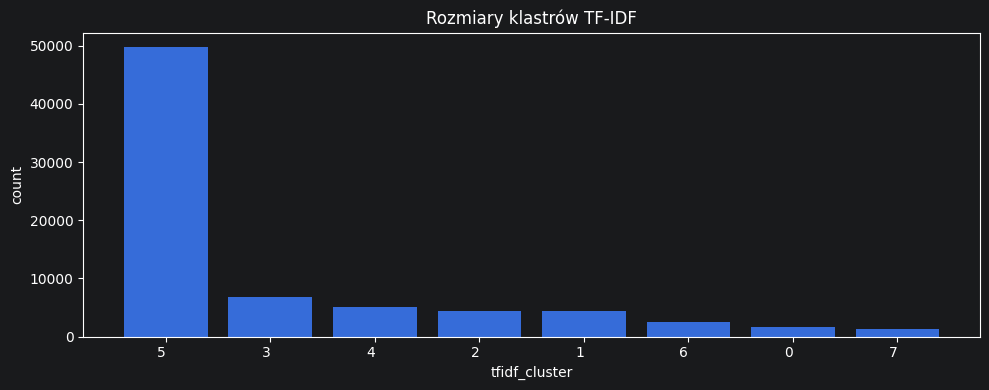

In [22]:
try:
    from sklearn.cluster import MiniBatchKMeans, KMeans
    from sklearn.feature_extraction.text import TfidfVectorizer

    text_for_clustering = (
        df_features["prompt_str"].fillna("")
        + "\n"
        + df_features["source_context_str"].fillna("").str[:2000]
    )
    n_records = len(text_for_clustering)
    if n_records >= 5:
        n_clusters = min(8, max(2, int(round(math.sqrt(n_records / 2)))))
        vectorizer = TfidfVectorizer(
            max_features=5000,
            ngram_range=(1, 2),
            min_df=1 if n_records < 50 else 2,
            stop_words="english",
        )
        X = vectorizer.fit_transform(text_for_clustering)
        Clusterer = MiniBatchKMeans if n_records > 1000 else KMeans
        clusterer = Clusterer(n_clusters=n_clusters, random_state=42, n_init="auto")
        df_features["tfidf_cluster"] = clusterer.fit_predict(X)

        cluster_summary = (
            df_features
            .groupby("tfidf_cluster")
            .agg(
                records=("_id", "count"),
                question_types=("question_type", lambda s: dict(Counter(s))),
                example_prompt=("prompt", "first"),
                example_answer=("reference_output", "first"),
            )
            .reset_index()
            .sort_values("records", ascending=False)
        )

        terms = np.array(vectorizer.get_feature_names_out())
        centers = clusterer.cluster_centers_
        top_terms = []
        for i in range(n_clusters):
            order = centers[i].argsort()[::-1][:12]
            top_terms.append(", ".join(terms[order]))
        cluster_summary["top_terms"] = cluster_summary["tfidf_cluster"].map(dict(enumerate(top_terms)))
        display(cluster_summary)

        plot_bar_from_freq(
            freq_table(df_features["tfidf_cluster"], "tfidf_cluster"),
            "tfidf_cluster",
            title="Rozmiary klastrów TF-IDF",
            rotation=0,
        )
    else:
        print("Za mało rekordów do sensownego klastrowania TF-IDF. Minimum: 5.")
except Exception as exc:
    print("Pominięto klastrowanie TF-IDF, bo scikit-learn nie jest dostępny albo wystąpił błąd:", repr(exc))

## 12. Rekomendowany split train/test bez leakage'u kodu

Jeżeli dataset będzie używany do trenowania lub ewaluacji modelu, dzielimy dane grupami po `source_context_hash`. Dzięki temu ten sam fragment kodu nie trafi jednocześnie do train i test.

In [23]:
def group_split_by_code(data, test_size=0.2, random_state=42):
    data = data.copy()
    groups = data["source_context_hash"].astype(str)
    if groups.nunique() < 2:
        data["split"] = "train"
        return data
    try:
        from sklearn.model_selection import GroupShuffleSplit
        splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        train_idx, test_idx = next(splitter.split(data, groups=groups))
        data["split"] = "test"
        data.loc[train_idx, "split"] = "train"
    except Exception:
        rng = np.random.default_rng(random_state)
        unique_groups = np.array(sorted(groups.unique()))
        n_test = max(1, int(round(len(unique_groups) * test_size)))
        test_groups = set(rng.choice(unique_groups, size=n_test, replace=False))
        data["split"] = np.where(groups.isin(test_groups), "test", "train")
    return data

split_df = group_split_by_code(df_features, test_size=0.2, random_state=42)

split_report = (
    split_df
    .groupby("split")
    .agg(
        records=("_id", "count"),
        unique_code_contexts=("source_context_hash", "nunique"),
        avg_difficulty=("difficulty_score", "mean"),
        pct_boolean=("is_boolean_answer", "mean"),
        pct_prompt_leakage=("potential_prompt_leakage", "mean"),
        pct_extractive_code=("potential_extractive_from_code", "mean"),
    )
    .reset_index()
)
for col in ["pct_boolean", "pct_prompt_leakage", "pct_extractive_code"]:
    split_report[col] = split_report[col] * 100

display(split_report)

# Kontrola: żaden hash kodu nie powinien być w obu splitach.
train_hashes = set(split_df.loc[split_df["split"].eq("train"), "source_context_hash"])
test_hashes = set(split_df.loc[split_df["split"].eq("test"), "source_context_hash"])
overlap_hashes = train_hashes & test_hashes
print(f"Liczba source_context_hash obecnych jednocześnie w train i test: {len(overlap_hashes)}")

split_df[["_id", "prompt_id", "source_context_hash", "split"]].head()

,split,records,unique_code_contexts,avg_difficulty,pct_boolean,pct_prompt_leakage,pct_extractive_code
0,test,15256,9747,5.371215,1.710802,1.560042,7.308600
1,train,60603,38987,5.388495,1.717737,1.745788,7.214164


Liczba source_context_hash obecnych jednocześnie w train i test: 0


,_id,prompt_id,source_context_hash,split
0,pr_codeqa_000001,pr_codeqa_000001,b666d2e3d1133b4d7111ecda33d7861a,train
1,pr_codeqa_000002,pr_codeqa_000002,b666d2e3d1133b4d7111ecda33d7861a,train
2,pr_codeqa_000003,pr_codeqa_000003,cea3e4beca7cfdb0f4cce0e907d1a99c,train
3,pr_codeqa_000004,pr_codeqa_000004,cea3e4beca7cfdb0f4cce0e907d1a99c,train
4,pr_codeqa_000005,pr_codeqa_000005,6126b21b260754cf89c9de3e71c36c9b,train


## 13. Eksport wyników analizy

Poniższa komórka zapisuje najważniejsze tabele do katalogu `analysis_outputs`. Dzięki temu można wykorzystać wyniki w raporcie, dashboardzie albo kolejnym notebooku.

In [24]:
OUTPUT_DIR = Path("analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Tabele zbiorcze
quality_report.to_csv(OUTPUT_DIR / "quality_report.csv", index=False)
question_type_freq.to_csv(OUTPUT_DIR / "question_type_frequency.csv", index=False)
answer_type_freq.to_csv(OUTPUT_DIR / "answer_type_frequency.csv", index=False)
top_answers.to_csv(OUTPUT_DIR / "top_answers.csv", index=False)
tag_freq.to_csv(OUTPUT_DIR / "tag_frequency.csv", index=False)
code_groups.to_csv(OUTPUT_DIR / "code_context_groups.csv", index=False)
leakage_summary.to_csv(OUTPUT_DIR / "leakage_summary.csv", index=False)
baseline_report.to_csv(OUTPUT_DIR / "baseline_report.csv", index=False)
split_report.to_csv(OUTPUT_DIR / "split_report.csv", index=False)
split_df[["_id", "prompt_id", "source_context_hash", "split"]].to_csv(OUTPUT_DIR / "recommended_group_split.csv", index=False)

# Pełna tabela cech: zapisujemy tylko kolumny bez problematycznych struktur, żeby CSV był wygodny do przeglądania.
flat_cols = [
    c for c in df_features.columns
    if c not in {"source_metadata", "tags", "tags_list", "function_names", "class_names", "call_names_top"}
]
df_features[flat_cols].to_csv(OUTPUT_DIR / "records_with_features.csv", index=False)

print(f"Zapisano wyniki do: {OUTPUT_DIR.resolve()}")
print("Pliki:")
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", p.name)

Zapisano wyniki do: C:\projekty\genai_analysis\analysis_outputs
Pliki:
- answer_type_frequency.csv
- baseline_report.csv
- code_context_groups.csv
- leakage_summary.csv
- quality_report.csv
- question_type_frequency.csv
- recommended_group_split.csv
- records_with_features.csv
- split_report.csv
- tag_frequency.csv
- top_answers.csv


## 14. Automatyczne podsumowanie do raportu

Ta komórka generuje krótkie, tekstowe podsumowanie najważniejszych obserwacji. Po uruchomieniu na pełnej bazie można je wkleić do raportu lub potraktować jako checklistę do dalszej analizy.

In [25]:
n = len(df_features)
unique_code = df_features["source_context_hash"].nunique()
q_yes_no_pct = df_features["question_type"].eq("yes_no").mean() * 100
bool_pct = df_features["is_boolean_answer"].mean() * 100
prompt_leak_pct = df_features["potential_prompt_leakage"].mean() * 100
extractive_pct = df_features["potential_extractive_from_code"].mean() * 100
code_duplicate_pct = df_features["source_context_hash"].duplicated(keep=False).mean() * 100
ast_ok_pct = df_features["ast_parse_ok"].mean() * 100 if "ast_parse_ok" in df_features else np.nan
majority_acc_pct = majority_answer_accuracy * 100

summary_md = f"""
### Podsumowanie analizy

- Liczba rekordów: **{n:,}**.
- Liczba unikalnych fragmentów kodu `source_context`: **{unique_code:,}**.
- Rekordy współdzielące `source_context` z innymi rekordami: **{code_duplicate_pct:.1f}%**.
- Udział pytań typu yes/no: **{q_yes_no_pct:.1f}%**.
- Udział odpowiedzi boolean: **{bool_pct:.1f}%**.
- Najczęstsza odpowiedź jako naiwny baseline osiągnęłaby około **{majority_acc_pct:.1f}%** exact match.
- Potencjalny leakage z promptu: **{prompt_leak_pct:.1f}%** rekordów.
- Odpowiedzi potencjalnie ekstrakcyjne z kodu: **{extractive_pct:.1f}%** rekordów.
- Kod parsowalny przez Python AST: **{ast_ok_pct:.1f}%** rekordów.

### Najważniejsze rekomendacje

1. Przy trenowaniu/testowaniu dziel dane po `source_context_hash`, nie losowo po rekordach.
2. Raportuj metryki osobno dla pytań `yes_no`, pytań `what/how/...` oraz odpowiedzi boolean i frazowych.
3. Przejrzyj ręcznie próbkę rekordów z `potential_prompt_leakage=True`.
4. Przejrzyj najtrudniejsze rekordy według `difficulty_score`, bo często ujawniają błędne referencje albo nietypowe konstrukcje kodu.
5. Porównuj modele z baseline'ami: najczęstsza odpowiedź, majority boolean, prompt-only i code-only.
"""

display(Markdown(summary_md))


### Podsumowanie analizy

- Liczba rekordów: **75,859**.
- Liczba unikalnych fragmentów kodu `source_context`: **48,734**.
- Rekordy współdzielące `source_context` z innymi rekordami: **59.5%**.
- Udział pytań typu yes/no: **1.7%**.
- Udział odpowiedzi boolean: **1.7%**.
- Najczęstsza odpowiedź jako naiwny baseline osiągnęłaby około **0.9%** exact match.
- Potencjalny leakage z promptu: **1.7%** rekordów.
- Odpowiedzi potencjalnie ekstrakcyjne z kodu: **7.2%** rekordów.
- Kod parsowalny przez Python AST: **97.8%** rekordów.

### Najważniejsze rekomendacje

1. Przy trenowaniu/testowaniu dziel dane po `source_context_hash`, nie losowo po rekordach.
2. Raportuj metryki osobno dla pytań `yes_no`, pytań `what/how/...` oraz odpowiedzi boolean i frazowych.
3. Przejrzyj ręcznie próbkę rekordów z `potential_prompt_leakage=True`.
4. Przejrzyj najtrudniejsze rekordy według `difficulty_score`, bo często ujawniają błędne referencje albo nietypowe konstrukcje kodu.
5. Porównuj modele z baseline'ami: najczęstsza odpowiedź, majority boolean, prompt-only i code-only.
